In [62]:
# AQUASTAT Database Water Stress
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


In [63]:
# importing data
df_water_stress = pd.read_csv('data/AQUASTAT Dissemination System.csv')

df_water_stress.head()


,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
0,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Afghanistan,2016,54.757019,%,E,False
1,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Afghanistan,2017,54.757019,%,E,False
2,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Afghanistan,2018,54.757019,%,E,False
3,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Afghanistan,2019,54.757019,%,E,False
4,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Afghanistan,2020,54.757019,%,E,False


In [64]:
# checking and handling missing values 
for column in df_water_stress.columns:
    print(f"Null Values in column '{column}' are: ", df_water_stress[column].isnull().sum())
    

Null Values in column 'VariableGroup' are:  0
Null Values in column 'Subgroup' are:  0
Null Values in column 'Variable' are:  0
Null Values in column 'Area' are:  0
Null Values in column 'Year' are:  0
Null Values in column 'Value' are:  0
Null Values in column 'Unit' are:  0
Null Values in column 'Symbol' are:  0
Null Values in column 'IsAggregate' are:  0


In [65]:
print(df_water_stress['Area'].unique())
print(df_water_stress['Year'].unique())


['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Australia and New Zealand' 'Austria'
 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium'
 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Central Asia'
 'Central and Southern Asia' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' "Côte d'Ivoire"
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Eastern Asia' 'Eastern and South-Eastern Asia'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Europe' 'Europe and Northern America' 'Fiji'
 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'

In [66]:
# 'Year' is an integer
df_water_stress['Year'] = pd.to_numeric(df_water_stress['Year'], errors='coerce')

# 'Value' is numeric
df_water_stress['Value'] = pd.to_numeric(df_water_stress['Value'], errors='coerce')

water_stress_nl = df_water_stress[(df_water_stress['Area'] == 'Netherlands (Kingdom of the)') &
    (df_water_stress['Variable'] == 'SDG 6.4.2. Water Stress')].copy()

# sort by year
water_stress_nl.sort_values(by='Year', inplace=True)

water_stress_nl.sample(7)
             


,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
859,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2021,16.075663,%,E,False
855,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2017,15.029808,%,E,False
858,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2020,16.803561,%,E,False
860,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2022,16.658507,%,E,False
856,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2018,16.366984,%,E,False
857,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2019,17.000607,%,E,False
854,Water use,Pressure on water resources,SDG 6.4.2. Water Stress,Netherlands (Kingdom of the),2016,15.233340,%,E,False


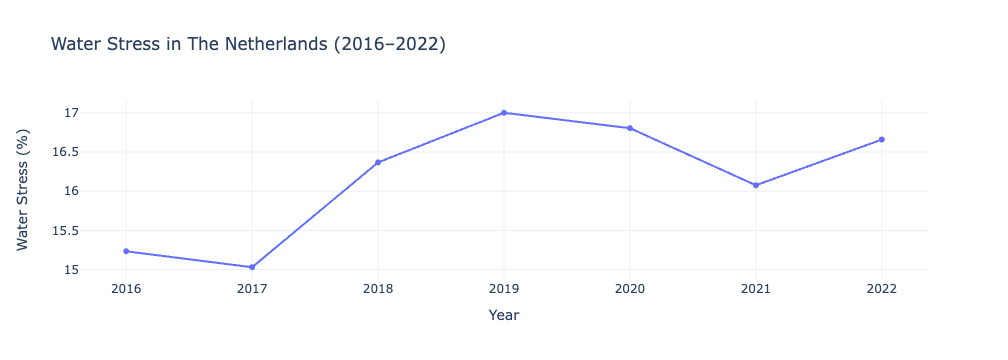

In [68]:
# visualization 1: change in water stress in nl 
fig = px.line(
    water_stress_nl,
    x='Year',
    y='Value',
    title='Water Stress in The Netherlands (2016–2022)',
    labels={'Value': 'Water Stress (%)'},
    markers=True
)

fig.update_layout(template='plotly_white')
fig.write_html("docs/data/visual_charts_graphs/netherlands_water_stress.html")
fig.show()

In [69]:
# focusing on global 
# making sure 'Year' is an integer
df_water_stress['Year'] = pd.to_numeric(df_water_stress['Year'], errors='coerce')

# making sure 'Value' is numeric
df_water_stress['Value'] = pd.to_numeric(df_water_stress['Value'], errors='coerce')

water_stress_global = df_water_stress[(df_water_stress['Variable'] == 'SDG 6.4.2. Water Stress')].copy()
water_stress_global.dropna(subset=['Value'], inplace=True)

water_stress_global.head

<bound method NDFrame.head of      VariableGroup                     Subgroup                 Variable  \
0        Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
1        Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
2        Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
3        Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
4        Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
...            ...                          ...                      ...   
1388     Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
1389     Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
1390     Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
1391     Water use  Pressure on water resources  SDG 6.4.2. Water Stress   
1392     Water use  Pressure on water resources  SDG 6.4.2. Water Stress   

             Area  Year      Value Unit Symbol  IsAggrega

In [70]:
# List of countries from 'Area' to exclude
excluded_countries = ['World', 'Europe', 'Asia', 'High-income countries', 'Low-income countries','European Union (27)', 
                      'Least Developed Countries', 'Western Asia', 'Sub-Saharan Africa', 'Southern Asia', 'South-eastern Asia',
                      'Oceania', 'Oceania (excluding Australia and New Zealand)', 'Northern Africa','Northern Africa and Western Asia', 'Northern America', 'Latin America and the Caribbean',
                      'Land Locked Developing Countries', 'Europe and Northern America', 'Eastern Asia', 'Eastern and South-Eastern Asia', 
                      'Central Asia','Central and Southern Asia']

In [71]:
global_stress = water_stress_global[~water_stress_global['Area'].isin(excluded_countries)].copy()

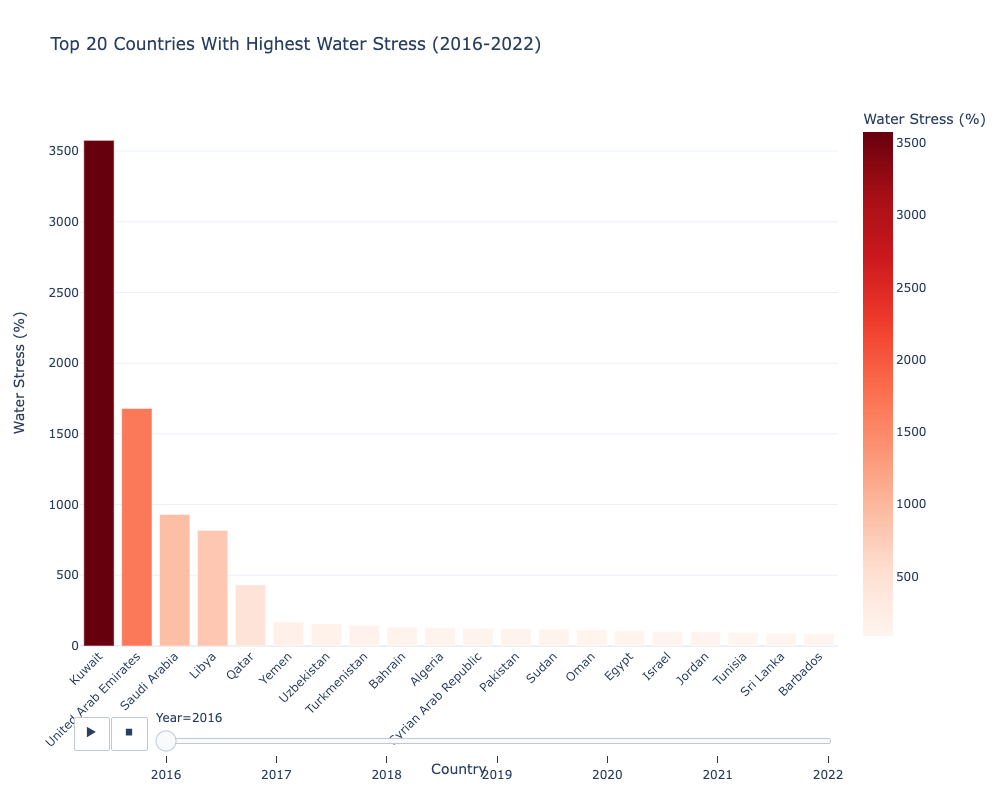

In [72]:
# visualization 2: top 20 countries with higest water stress values

highest_stress = (global_stress.groupby('Year', group_keys=False).apply(lambda x: x.nlargest(20, 'Value')))
fig = px.bar(
    highest_stress,
    x='Area',
    y='Value',
    color='Value',
    color_continuous_scale= 'Reds',
    animation_frame='Year',
    range_y=[0, highest_stress['Value'].max() + 10],
    title='Top 20 Countries With Highest Water Stress (2016-2022)',
    labels={'Value': 'Water Stress (%)', 'Area': 'Country'}
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=800,
    transition={'duration': 500}
)

fig.show()

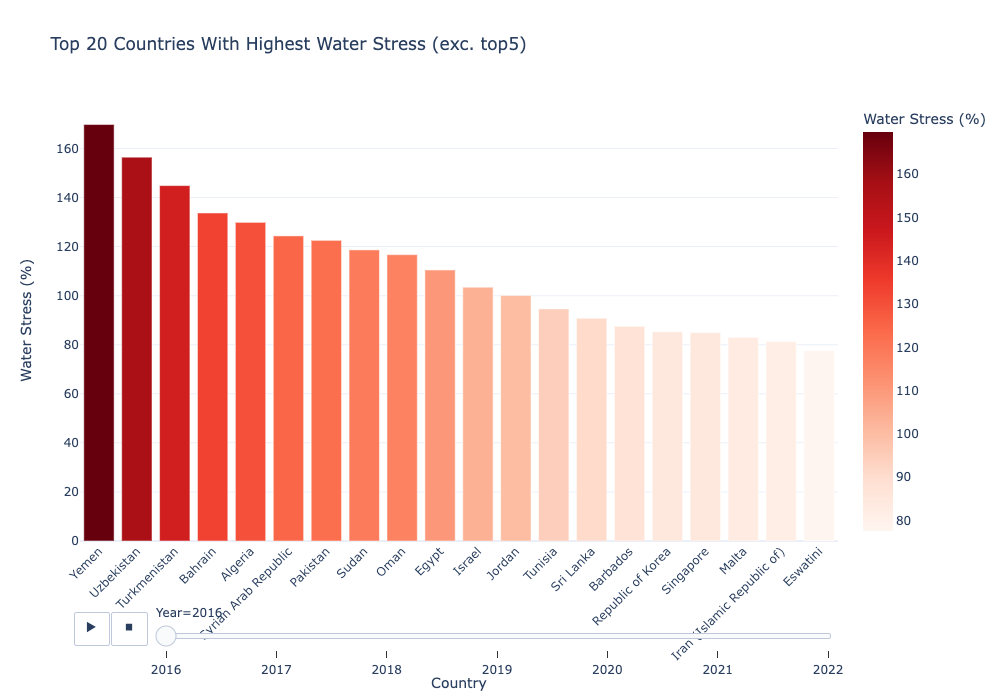

In [73]:
# visualisation 3: top 20 countries with highest water stress (excluding Kuwait, UAE, Saudi Arabia, Libya, Qatar)
excluded_countries_out = ['World', 'Europe', 'Asia', 'High-income countries', 'Low-income countries','European Union (27)', 
                      'Least Developed Countries', 'Western Asia', 'Sub-Saharan Africa', 'Southern Asia', 'South-eastern Asia',
                      'Oceania', 'Oceania (excluding Australia and New Zealand)', 'Northern Africa','Northern Africa and Western Asia', 'Northern America', 'Latin America and the Caribbean',
                      'Land Locked Developing Countries', 'Europe and Northern America', 'Eastern Asia', 'Eastern and South-Eastern Asia', 
                      'Central Asia','Central and Southern Asia', 'Kuwait', 'United Arab Emirates', 'Saudi Arabia', 'Libya', 'Qatar'] 

global_stress_out = water_stress_global[~water_stress_global['Area'].isin(excluded_countries_out)].copy()

highest_stress_out = (global_stress_out.groupby('Year', group_keys=False).apply(lambda x: x.nlargest(20, 'Value')))
fig = px.bar(
    highest_stress_out,
    x='Area',
    y='Value',
    color='Value',
    color_continuous_scale='Reds',
    animation_frame='Year',
    range_y=[0, highest_stress_out['Value'].max() + 10],
    title='Top 20 Countries With Highest Water Stress (exc. top5)',
    labels={'Value': 'Water Stress (%)', 'Area': 'Country'}
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=700,
    transition={'duration': 500}
)

fig.write_html("docs/data/visual_charts_graphs/top_20_water_stress_excluding.html")
fig.show()


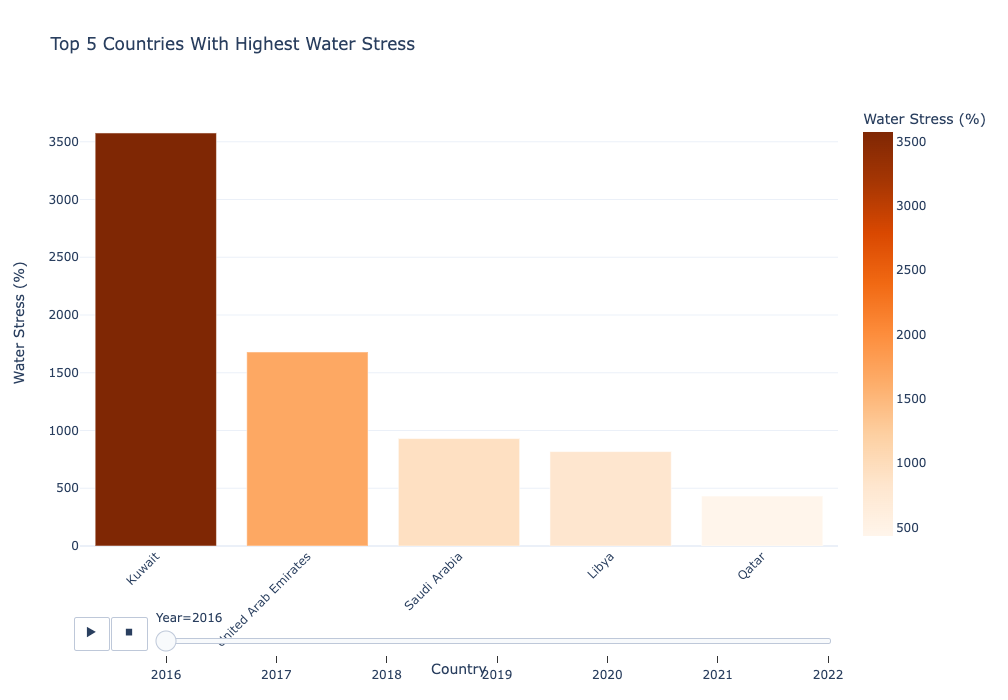

In [74]:
# visualisation 4: top 5 countries with highest water stress (Kuwait, UAE, Saudi Arabia, Libya, Qatar)

# filtering top 5 countries
top_5_countries = ['Kuwait', 'United Arab Emirates', 'Saudi Arabia', 'Libya', 'Qatar']
global_stress_top_5 = water_stress_global[water_stress_global['Area'].isin(top_5_countries)].copy()

highest_stress_top5 = (global_stress_top_5.groupby('Year', group_keys=False).apply(lambda x: x.nlargest(20, 'Value')))
fig = px.bar(
    highest_stress_5,
    x='Area',
    y='Value',
    color='Value',
    color_continuous_scale='Oranges',
    animation_frame='Year',
    range_y=[0, highest_stress_5['Value'].max() + 10],
    title='Top 5 Countries With Highest Water Stress',
    labels={'Value': 'Water Stress (%)', 'Area': 'Country'}
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=700,
    transition={'duration': 500}
)

fig.write_html("docs/data/visual_charts_graphs/top_5_water_stress_countries.html")
fig.show()

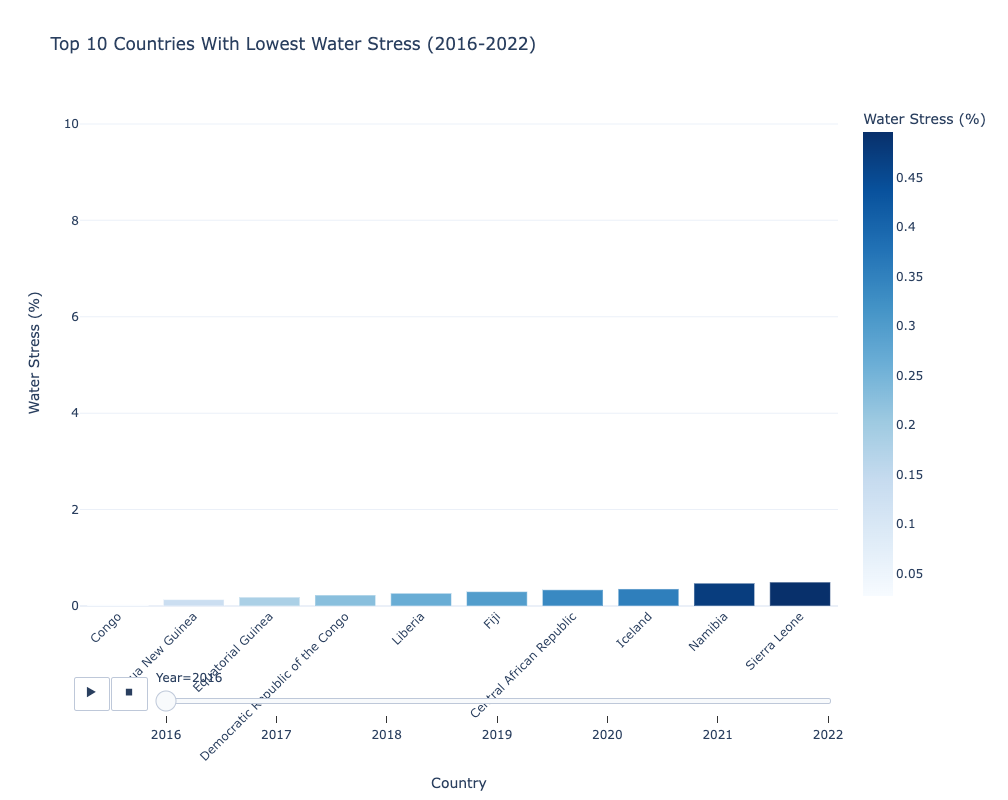

In [75]:
# visualization 5: top 10 countries with lowest water stress values

lowest_stress = (global_stress.groupby('Year', group_keys=False).apply(lambda x: x.nsmallest(10, 'Value')))
fig = px.bar(
    lowest_stress,
    x='Area',
    y='Value',
    color='Value',
    color_continuous_scale= 'Blues',
    animation_frame='Year',
    range_y=[0, lowest_stress['Value'].max() + 10],
    title='Top 10 Countries With Lowest Water Stress (2016-2022)',
    labels={'Value': 'Water Stress (%)', 'Area': 'Country'}
)

fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=800,
    transition={'duration': 500}
)

fig.show()

In [77]:
# visualization 6: map with water stress classified

# classify countries water stress as 'Low', 'Medium', 'High' 
def classify_stress(value):
    if value <= 25: 
        return 'Low'
    elif value <= 75:
        return 'Medium'
    else:
        return 'High'
    
global_stress['Variable'] = global_stress['Value'].apply(classify_stress)


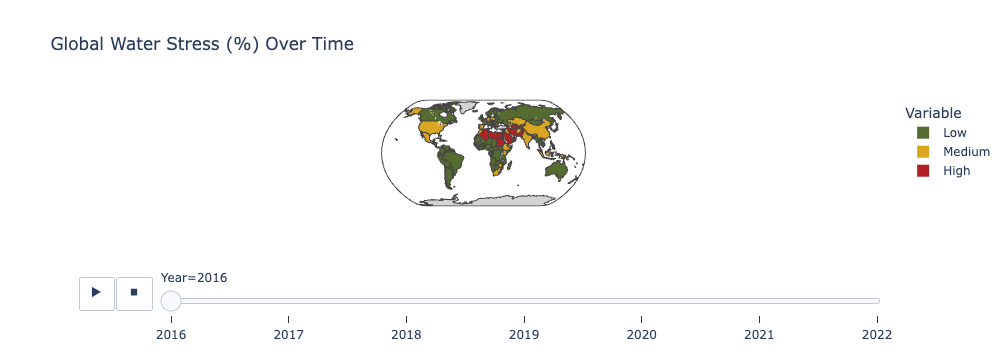

In [79]:
# plotting map
fig = px.choropleth(
    global_stress,
    locations='Area',
    locationmode='country names',
    color='Variable',
    hover_name='Area',
    hover_data={'Year': True, 'Value': True, 'Variable': True},
    animation_frame='Year',
    category_orders={'Variable': ['Low', 'Medium', 'High']},
    color_discrete_map={'Low': '#556B2F','Medium': '#DAA520','High': '#b22222'},
    title='Global Water Stress (%) Over Time',
)

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

fig.show()


# Save to interactive HTML
fig.write_html("docs/data/visual_charts_graphs/water_stress_map.html", include_plotlyjs="cdn", full_html=True)